In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
load_dotenv()
import os

In [4]:
def get_groq_llm():
    return ChatOpenAI(
        model="openai/gpt-oss-20b",
        base_url="https://api.groq.com/openai/v1",
        api_key=os.getenv("GROQ_API_KEY"),
        temperature=0.3, max_tokens=2000
    )

llm = get_groq_llm()

In [5]:
class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str


In [6]:
def generate_joke(state: JokeState):

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt).content

    return {'joke': response}

In [7]:
def generate_explanation(state: JokeState):

    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = llm.invoke(prompt).content

    return {'explanation': response}

In [8]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

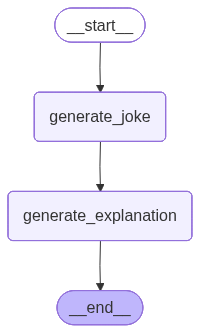

In [9]:
workflow

In [10]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic':'pizza'}, config=config1)

{'topic': 'pizza',
 'joke': 'Why did the pizza start a band?  \n\nBecause it had the perfect *crust* for a *topping* of rhythm! 🍕🎸',
 'explanation': '**Why the joke works – a quick breakdown**\n\n| Element | Pizza meaning | Musical meaning | How the pun ties them together |\n|---------|---------------|-----------------|--------------------------------|\n| **Crust** | The flat, doughy base that holds the pizza together. | “Crust” isn’t a standard music term, but it can be read as a *foundation* or *base* for a song—just as a good rhythm section underpins a track. | The joke says the pizza “had the perfect crust” – i.e., it had the perfect base for music. |\n| **Topping** | The sauce, cheese, pepperoni, veggies, etc., that sit on top of the crust. | In music, a “topping” can be any extra layer or embellishment (think of a solo, a hook, or a melodic line that “tops” the beat). | The punchline calls it a “topping of rhythm,” playing on the idea that the pizza’s toppings are literally a “to

In [11]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza start a band?  \n\nBecause it had the perfect *crust* for a *topping* of rhythm! 🍕🎸', 'explanation': '**Why the joke works – a quick breakdown**\n\n| Element | Pizza meaning | Musical meaning | How the pun ties them together |\n|---------|---------------|-----------------|--------------------------------|\n| **Crust** | The flat, doughy base that holds the pizza together. | “Crust” isn’t a standard music term, but it can be read as a *foundation* or *base* for a song—just as a good rhythm section underpins a track. | The joke says the pizza “had the perfect crust” – i.e., it had the perfect base for music. |\n| **Topping** | The sauce, cheese, pepperoni, veggies, etc., that sit on top of the crust. | In music, a “topping” can be any extra layer or embellishment (think of a solo, a hook, or a melodic line that “tops” the beat). | The punchline calls it a “topping of rhythm,” playing on the idea that the pizza’s toppings 

# ## Intermediate States

In [13]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza start a band?  \n\nBecause it had the perfect *crust* for a *topping* of rhythm! 🍕🎸', 'explanation': '**Why the joke works – a quick breakdown**\n\n| Element | Pizza meaning | Musical meaning | How the pun ties them together |\n|---------|---------------|-----------------|--------------------------------|\n| **Crust** | The flat, doughy base that holds the pizza together. | “Crust” isn’t a standard music term, but it can be read as a *foundation* or *base* for a song—just as a good rhythm section underpins a track. | The joke says the pizza “had the perfect crust” – i.e., it had the perfect base for music. |\n| **Topping** | The sauce, cheese, pepperoni, veggies, etc., that sit on top of the crust. | In music, a “topping” can be any extra layer or embellishment (think of a solo, a hook, or a melodic line that “tops” the beat). | The punchline calls it a “topping of rhythm,” playing on the idea that the pizza’s toppings

In [15]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'pasta'}, config=config2)

{'topic': 'pasta',
 'joke': 'Why did the spaghetti go to therapy?  \n\nBecause it couldn’t stop feeling *tortellini*—it was always *twisted* up in its own noodles!',
 'explanation': '**Why the joke works – a quick breakdown**\n\n| Element | What it is | Why it’s funny |\n|---------|------------|----------------|\n| **Anthropomorphism** | The spaghetti is treated like a person who can feel emotions and seek therapy. | It’s absurd to imagine a noodle with feelings, which immediately sets up a comedic premise. |\n| **Word‑play on “tortellini”** | “Tortellini” is a type of pasta that is literally twisted. The joke says the spaghetti “couldn’t stop feeling *tortellini*.” | The phrase sounds like “tortured” or “tortellini” (the pasta). It’s a pun that ties the emotional state (“feeling tortured”) to the literal shape of the pasta. |\n| **Double meaning of “twisted”** | “Twisted” can mean (1) physically twisted, as pasta is, and (2) mentally or emotionally tangled. | The line “it was always *

In [16]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti go to therapy?  \n\nBecause it couldn’t stop feeling *tortellini*—it was always *twisted* up in its own noodles!', 'explanation': '**Why the joke works – a quick breakdown**\n\n| Element | What it is | Why it’s funny |\n|---------|------------|----------------|\n| **Anthropomorphism** | The spaghetti is treated like a person who can feel emotions and seek therapy. | It’s absurd to imagine a noodle with feelings, which immediately sets up a comedic premise. |\n| **Word‑play on “tortellini”** | “Tortellini” is a type of pasta that is literally twisted. The joke says the spaghetti “couldn’t stop feeling *tortellini*.” | The phrase sounds like “tortured” or “tortellini” (the pasta). It’s a pun that ties the emotional state (“feeling tortured”) to the literal shape of the pasta. |\n| **Double meaning of “twisted”** | “Twisted” can mean (1) physically twisted, as pasta is, and (2) mentally or emotionally tangled. | The li

# ### Time Travel
# 
# ## we can go back to any previous node to do the execution again for debugging & changing the input as well


## so let's go to the pizza example where we got the topic & we want to go back to joke generation step & further steps.
## In order to do that we need to grab the checkpoint id where we got the topic. We can get it from the state history.


In [17]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti go to therapy?  \n\nBecause it couldn’t stop feeling *tortellini*—it was always *twisted* up in its own noodles!', 'explanation': '**Why the joke works – a quick breakdown**\n\n| Element | What it is | Why it’s funny |\n|---------|------------|----------------|\n| **Anthropomorphism** | The spaghetti is treated like a person who can feel emotions and seek therapy. | It’s absurd to imagine a noodle with feelings, which immediately sets up a comedic premise. |\n| **Word‑play on “tortellini”** | “Tortellini” is a type of pasta that is literally twisted. The joke says the spaghetti “couldn’t stop feeling *tortellini*.” | The phrase sounds like “tortured” or “tortellini” (the pasta). It’s a pun that ties the emotional state (“feeling tortured”) to the literal shape of the pasta. |\n| **Double meaning of “twisted”** | “Twisted” can mean (1) physically twisted, as pasta is, and (2) mentally or emotionally tangled. | The l

In [ ]:
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f14c786-2306-67c6-8000-82a49c58b68b"}}) ## checkpoint id from pizza run where we haver the topic but we need to generate the joke


StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f14c786-2306-67c6-8000-82a49c58b68b'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-05-10T13:58:55.232191+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f14c786-2304-6c14-bfff-49c46a6b0e9f'}}, tasks=(PregelTask(id='279db908-44c6-da52-f31f-abf5d38053c8', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why did the pizza start a band?  \n\nBecause it had the perfect *crust* for a *topping* of rhythm! 🍕🎸'}),), interrupts=())

In [19]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f14c786-2306-67c6-8000-82a49c58b68b"}})


{'topic': 'pizza',
 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to get a *crust* of a living! 🍕😄',
 'explanation': '**Why the joke works – a quick breakdown**\n\n| Element | What it is | Why it’s funny |\n|---------|------------|----------------|\n| **Pizza “applying for a job”** | A pizza is an inanimate food, so the idea that it could go to a job interview is absurd. | The absurdity of a pizza behaving like a human worker sets the stage for a pun. |\n| **“Crust of a living”** | A play on the phrase **“cost of living.”** The word *crust* (the outer part of a pizza) replaces *cost*. | 1. **Word‑play** – the joke hinges on the similarity between “crust” and “cost.” 2. **Pizza‑specific twist** – the pun only makes sense because we’re talking about pizza, so the “crust” is a literal part of the food. |\n| **“Living”** | In everyday language, “living” refers to income or a way to support oneself. | The phrase “cost of living” is a common expression about expenses. By s

# ## now we can see more Snapshots due to the re-execution

In [20]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to get a *crust* of a living! 🍕😄', 'explanation': '**Why the joke works – a quick breakdown**\n\n| Element | What it is | Why it’s funny |\n|---------|------------|----------------|\n| **Pizza “applying for a job”** | A pizza is an inanimate food, so the idea that it could go to a job interview is absurd. | The absurdity of a pizza behaving like a human worker sets the stage for a pun. |\n| **“Crust of a living”** | A play on the phrase **“cost of living.”** The word *crust* (the outer part of a pizza) replaces *cost*. | 1. **Word‑play** – the joke hinges on the similarity between “crust” and “cost.” 2. **Pizza‑specific twist** – the pun only makes sense because we’re talking about pizza, so the “crust” is a literal part of the food. |\n| **“Living”** | In everyday language, “living” refers to income or a way to support oneself. | The phrase “cost of living” is a common expression 

# #### Updating State

In [21]:
workflow.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f14c786-2306-67c6-8000-82a49c58b68b", "checkpoint_ns": ""}}, {'topic':'Burger'})


{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f14c7bc-11c9-6fd6-8001-b5a1f1d89a3b'}}

# ## now we have updated the state with topic as samosa, one more snapshot will be created

In [22]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'Burger'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f14c7bc-11c9-6fd6-8001-b5a1f1d89a3b'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-05-10T14:23:02.976272+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f14c786-2306-67c6-8000-82a49c58b68b'}}, tasks=(PregelTask(id='11ddebb0-704d-38b8-e266-ca5e66ecb319', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza apply for a job?\n\nBecause it wanted to get a *crust* of a living! 🍕😄', 'explanation': '**Why the joke works – a quick breakdown**\n\n| Element | What it is | Why it’s funny |\n|---------|------------|----------------|\n| **Pizza “applying for a job”** | A pizza is an inanimate food, so the idea that it could 

# ## and to execute the workflow from the updated state (samosa) we need to pass the checkpoint id of samosa snapshot



In [24]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f14c7bc-11c9-6fd6-8001-b5a1f1d89a3b"}})


{'topic': 'Burger',
 'joke': 'Why did the burger go to therapy?\n\nBecause it had too many “lettuce” problems and couldn’t stop feeling “grilled” over its “patty” of life!',
 'explanation': '**Why did the burger go to therapy?  \nBecause it had too many “lettuce” problems and couldn’t stop feeling “grilled” over its “patty” of life!**\n\n---\n\n### 1. The set‑up\n\nThe joke follows a classic “Why did X go to therapy?” format.  \nThat structure already signals that we’re about to hear a funny, absurd reason—usually something that turns a mundane situation into a punchline.\n\n### 2. Anthropomorphizing the burger\n\nThe humor comes from treating a burger (a food item) as if it were a person with emotions and mental health issues.  \nWe’re asked to imagine a burger *feeling* something, which is inherently ridiculous and sets the stage for the wordplay.\n\n### 3. The wordplay\n\n| Word in the punchline | Literal meaning | Pun / double‑meaning |\n|-----------------------|-----------------|-

In [25]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'Burger', 'joke': 'Why did the burger go to therapy?\n\nBecause it had too many “lettuce” problems and couldn’t stop feeling “grilled” over its “patty” of life!', 'explanation': '**Why did the burger go to therapy?  \nBecause it had too many “lettuce” problems and couldn’t stop feeling “grilled” over its “patty” of life!**\n\n---\n\n### 1. The set‑up\n\nThe joke follows a classic “Why did X go to therapy?” format.  \nThat structure already signals that we’re about to hear a funny, absurd reason—usually something that turns a mundane situation into a punchline.\n\n### 2. Anthropomorphizing the burger\n\nThe humor comes from treating a burger (a food item) as if it were a person with emotions and mental health issues.  \nWe’re asked to imagine a burger *feeling* something, which is inherently ridiculous and sets the stage for the wordplay.\n\n### 3. The wordplay\n\n| Word in the punchline | Literal meaning | Pun / double‑meaning |\n|-----------------------

# ### Fault Tolerance kind of similar as human in the loop (In HITL we do it perpupose fully using langraph interrupt)

In [ ]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time

In [ ]:
# 1. Define the state
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str
    step3: str

In [ ]:
# 2. Define steps
def step_1(state: CrashState) -> CrashState:
    print("✅ Step 1 executed")
    return {"step1": "done", "input": state["input"]}

def step_2(state: CrashState) -> CrashState:
    print("⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)")
    time.sleep(10)  # Simulate long-running hang
    return {"step2": "done"}

def step_3(state: CrashState) -> CrashState:
    print("✅ Step 3 executed")
    return {"step3": "done"}


In [ ]:
# 3. Build the graph
builder = StateGraph(CrashState)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.set_entry_point("step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

In [ ]:
graph

In [ ]:
try:
    print("▶️ Running graph: Please manually interrupt during Step 2...")
    graph.invoke({"input": "start"}, config={"configurable": {"thread_id": 'thread-1'}})
except KeyboardInterrupt:
    print("❌ Kernel manually interrupted (crash simulated).")


In [ ]:
graph.get_state({"configurable": {"thread_id": 'thread-1'}})

In [ ]:
# 6. Re-run to show fault-tolerant resume
print("\n🔁 Re-running the graph to demonstrate fault tolerance...")
final_state = graph.invoke(None, config={"configurable": {"thread_id": 'thread-1'}})
print("\n✅ Final State:", final_state)



In [26]:
list(graph.get_state_history({"configurable": {"thread_id": 'thread-1'}}))

AttributeError: 'StateGraph' object has no attribute 'get_state_history'